# Forecasting Glucose Levels in Type 1 Diabetes Using Time-Series Approaches

**Student Name:** Muhammad Umer Mehmood 

**Student ID:** 23102319 

**Supervisor:** Ralf Napiwotzki    

---

## About the Dataset
The **GlucoBench** repository, which gathers extensive and longitudinal records of Continuous Glucose Monitoring (CGM) data, is the source of this dataset. Both descriptive and predictive studies are made possible by the data's integration of glucose levels with clinical, lifestyle, and demographic data.

A **single glucose measurement** from a particular patient at a particular time point is represented by each row.

## Key Features
- **Core:** Patient ID, Blood Glucose (target), Timestamp
- **Demographics:** Gender, Race, Education Level, Income, Marital Status
- **Clinical History:** Hypertension, Diabetes Duration, Comorbidities, Complications
- **Lifestyle:** Exercise Habits, Alcohol Use, Dietary Supplements
- **Medications:** Binary indicators for common prescriptions

## Purpose of Analysis
Determine the glucose patterns unique to each patient.
Conduct sophisticated statistical and visual evaluations.
Create and assess forecasting models to aid in the management of diabetes
Provide useful information about how clinical, lifestyle, and demographic factors relate to glycaemic management.

**Data Source:** [GlucoBench](https://github.com/IrinaStatsLab/GlucoBench)

In [15]:
# --- Core ---
import numpy as np
import pandas as pd
import os
import warnings
import random
warnings.filterwarnings('ignore')

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# --- Preprocessing & Metrics ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, GRU, Conv1D, MaxPooling1D,
                                      Dense, Dropout, Flatten,
                                      BatchNormalization, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam



In [16]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✅ GPU is ACTIVE!")
    for gpu in gpus:
        print(f"   Device: {gpu.name}")
    # Allow memory growth to avoid OOM errors during training
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️  No GPU detected. Running on CPU.")
    print("   → Go to Kaggle Settings > Accelerator > GPU T4 x2")

✅ GPU is ACTIVE!
   Device: /physical_device:GPU:0
   Device: /physical_device:GPU:1


In [4]:
# --- Reproducibility ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# --- Sequence Configuration (for LSTM/GRU/CNN) ---
SEQUENCE_LENGTH  = 12   # 12 steps x 5 min = 1 hour of history as input
FORECAST_HORIZON = 6    # Predict next 6 steps = 30 minutes ahead

# --- Training Configuration ---
BATCH_SIZE    = 64
EPOCHS        = 100     # EarlyStopping will stop before if needed
PATIENCE      = 10      # EarlyStopping patience
LEARNING_RATE = 0.001

# --- Train / Val / Test Split Ratio ---
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# --- Glucose Clinical Thresholds (mg/dL) ---
HYPO_THRESHOLD  = 70    # Below = Hypoglycemia (dangerous LOW)
NORMAL_LOW      = 70
NORMAL_HIGH     = 180
HYPER_THRESHOLD = 180   # Above = Hyperglycemia (dangerous HIGH)

# --- Plot Style ---
plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {
    'glucose' : '#2196F3',
    'hypo'    : '#F44336',
    'hyper'   : '#FF9800',
    'normal'  : '#4CAF50',
    'lstm'    : '#9C27B0',
    'gru'     : '#00BCD4',
    'cnn'     : '#FF5722',
}

print("✅ Configuration set!")
print(f"   Sequence Length  : {SEQUENCE_LENGTH} steps ({SEQUENCE_LENGTH * 5} mins of history)")
print(f"   Forecast Horizon : {FORECAST_HORIZON} steps ({FORECAST_HORIZON * 5} mins ahead)")
print(f"   Batch Size       : {BATCH_SIZE}")
print(f"   Max Epochs       : {EPOCHS}")
print(f"   Train/Val/Test   : {int(TRAIN_RATIO*100)}% / {int(VAL_RATIO*100)}% / {int(TEST_RATIO*100)}%")

✅ Configuration set!
   Sequence Length  : 12 steps (60 mins of history)
   Forecast Horizon : 6 steps (30 mins ahead)
   Batch Size       : 64
   Max Epochs       : 100
   Train/Val/Test   : 70% / 15% / 15%


In [8]:
df = pd.read_csv('/kaggle/input/datasets/umercheena/gcm-dataset/weinstock.csv')

print(f"✅ Loaded! {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"👥 Patients: {df['id'].nunique()}")
print(f"📋 Columns: {list(df.columns)}")

✅ Loaded! 647,858 rows × 41 columns
👥 Patients: 200
📋 Columns: ['id', 'gl', 'time', 'Gender', 'Race', 'EduLevel', 'AnnualInc', 'MaritalStatus', 'DaysWkEx', 'DaysWkDrinkAlc', 'DaysMonBingeAlc', 'T1DDiagAge', 'NumHospDKA', 'NumSHSinceT1DDiag', 'InsDeliveryMethod', 'UnitsInsTotal', 'NumMeterCheckDay', 'Height', 'Weight', 'Hypertension', 'Hyperlipidemia', 'Hypothyroidism', 'Depression', 'Coronary artery disease', 'Diabetic peripheral neuropathy', 'Dyslipidemia', 'Chronic kidney disease', 'Osteoporosis', 'Proliferative diabetic retinopathy', 'Hypercholesterolemia', 'Erectile dysfunction', 'Type I diabetes mellitus', 'Aspirin', 'Simvastatin', 'Lisinopril', 'Vitamin D', 'Multivitamin preparation', 'Omeprazole', 'atorvastatin', 'Synthroid', 'vitamin D3']


In [9]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['id', 'time']).reset_index(drop=True)

print(f"✅ Datetime parsed and sorted!")
print(f"   Time range: {df['time'].min()}  →  {df['time'].max()}")
print(f"   Sample:\n{df[['id', 'gl', 'time']].head(5)}")

✅ Datetime parsed and sorted!
   Time range: 1899-12-27 20:28:58  →  1900-03-22 12:33:51
   Sample:
   id     gl                time
0   1  223.0 1900-01-01 18:35:14
1   1  221.0 1900-01-01 18:40:14
2   1  233.0 1900-01-01 18:45:14
3   1  223.0 1900-01-01 18:50:14
4   1  214.0 1900-01-01 18:55:14


## Statistics on Glucose
There are 647,858 readings in the dataset with **no missing values**, thus no imputation is necessary.
A poorly controlled T1D population with excessive glucose variability is indicated by a mean glucose of **173.86 mg/dL** around the hyperglycemia threshold and a high standard deviation of **82.54 mg/dL**.

In [10]:
print("📊 Glucose (gl) Statistics:")
print(df['gl'].describe().round(2))

print(f"\n🔴 Hypoglycemia  (< 70 mg/dL)  : {(df['gl'] < 70).sum():,}  ({(df['gl'] < 70).mean()*100:.1f}%)")
print(f"🟢 Normal        (70–180 mg/dL) : {((df['gl'] >= 70) & (df['gl'] <= 180)).sum():,}  ({((df['gl'] >= 70) & (df['gl'] <= 180)).mean()*100:.1f}%)")
print(f"🟠 Hyperglycemia (> 180 mg/dL)  : {(df['gl'] > 180).sum():,}  ({(df['gl'] > 180).mean()*100:.1f}%)")

print(f"\n❓ Missing glucose values: {df['gl'].isnull().sum()}")

📊 Glucose (gl) Statistics:
count    647858.00
mean        173.86
std          82.54
min          39.00
25%         112.00
50%         161.00
75%         223.00
max         401.00
Name: gl, dtype: float64

🔴 Hypoglycemia  (< 70 mg/dL)  : 48,839  (7.5%)
🟢 Normal        (70–180 mg/dL) : 333,033  (51.4%)
🟠 Hyperglycemia (> 180 mg/dL)  : 265,986  (41.1%)

❓ Missing glucose values: 0


## Distribution of Glucose
The histogram has a **right-skewed distribution** with a prominent spike at 401 mg/dL, which represents the maximum reading cap of the CGM sensor; preprocessing will take care of this.

The skew brought on by extremely high blood sugar levels is confirmed by Mean (173.9) > Median (161.0).

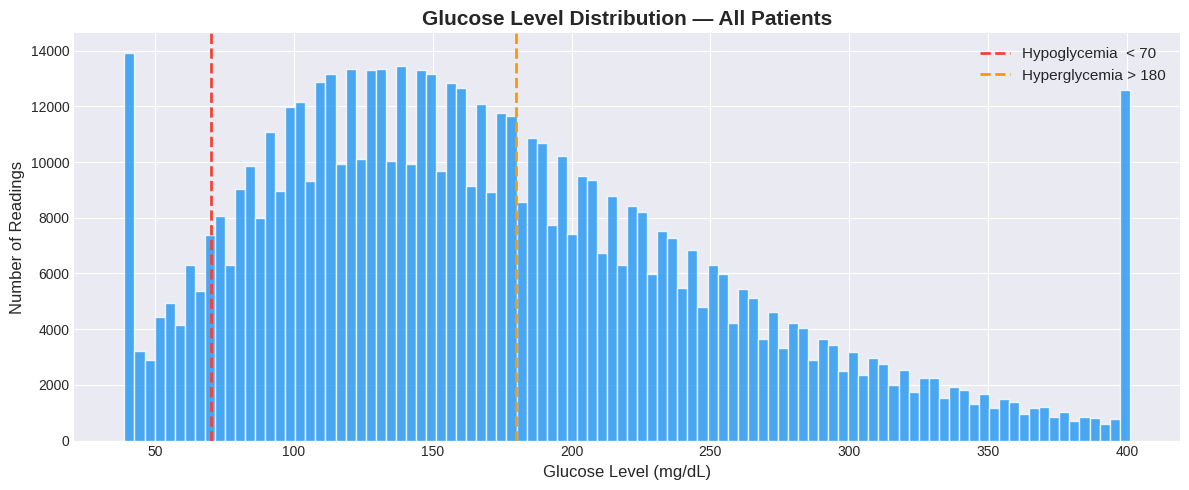

Mean  : 173.9 mg/dL
Median: 161.0 mg/dL
Std   : 82.5 mg/dL


In [11]:
plt.figure(figsize=(12, 5))

plt.hist(df['gl'], bins=100, color=COLORS['glucose'], edgecolor='white', alpha=0.8)

# Clinical threshold lines
plt.axvline(HYPO_THRESHOLD,  color=COLORS['hypo'],   linewidth=2, linestyle='--', label='Hypoglycemia  < 70')
plt.axvline(HYPER_THRESHOLD, color=COLORS['hyper'],  linewidth=2, linestyle='--', label='Hyperglycemia > 180')

plt.title('Glucose Level Distribution — All Patients', fontsize=15, fontweight='bold')
plt.xlabel('Glucose Level (mg/dL)', fontsize=12)
plt.ylabel('Number of Readings', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Mean  : {df['gl'].mean():.1f} mg/dL")
print(f"Median: {df['gl'].median():.1f} mg/dL")
print(f"Std   : {df['gl'].std():.1f} mg/dL")

## Distribution of Glucose Zones
Patients spend over half of their time in hazardous glucose zones since only **51.4%** of values fall inside the normal range. The high rate of **41.1%** hyperglycemia significantly 

explains why a precise deep learning forecasting method is necessary.

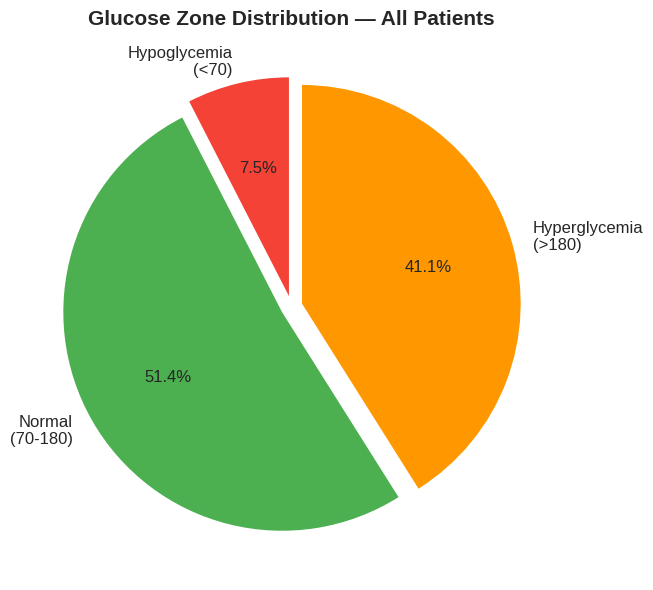

In [12]:
zones       = ['Hypoglycemia\n(<70)', 'Normal\n(70-180)', 'Hyperglycemia\n(>180)']
zone_counts = [
    (df['gl'] < 70).sum(),
    ((df['gl'] >= 70) & (df['gl'] <= 180)).sum(),
    (df['gl'] > 180).sum()
]
zone_colors = [COLORS['hypo'], COLORS['normal'], COLORS['hyper']]

plt.figure(figsize=(8, 6))
plt.pie(zone_counts,
        labels=zones,
        colors=zone_colors,
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0.05, 0.05),
        textprops={'fontsize': 12})

plt.title('Glucose Zone Distribution — All Patients', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Patient Time Series 
Patient 1 exhibits extremely **volatile and non-linear** glucose patterns, with a mean of **213.8 mg/dL** with quick spikes and dips within brief periods. The use of sequence-based deep learning models such as CNN, GRU, and LSTM is directly justified by this chaotic behaviour.

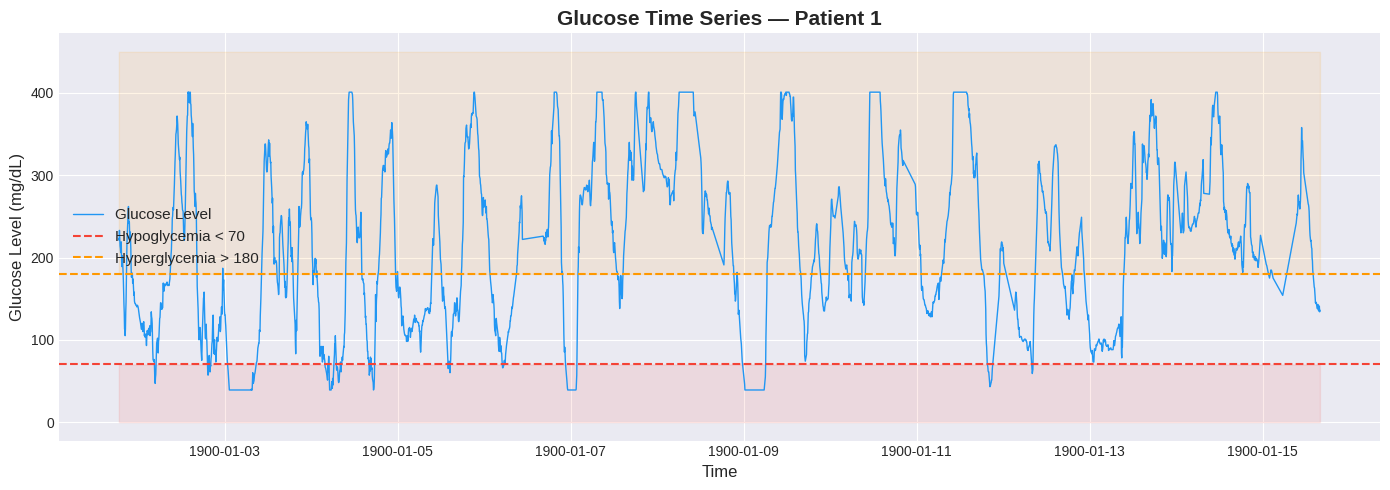

Patient 1 — Total readings : 3327
Mean glucose : 213.8 mg/dL


In [13]:
# Pick patient ID 1 as sample
patient = df[df['id'] == 1].copy()

plt.figure(figsize=(14, 5))

plt.plot(patient['time'], patient['gl'], 
         color=COLORS['glucose'], linewidth=1, label='Glucose Level')

# Clinical threshold lines
plt.axhline(HYPO_THRESHOLD,  color=COLORS['hypo'],  linewidth=1.5, 
            linestyle='--', label='Hypoglycemia < 70')
plt.axhline(HYPER_THRESHOLD, color=COLORS['hyper'], linewidth=1.5, 
            linestyle='--', label='Hyperglycemia > 180')

# Shade danger zones
plt.fill_between(patient['time'], 0, HYPO_THRESHOLD, 
                 alpha=0.1, color=COLORS['hypo'])
plt.fill_between(patient['time'], HYPER_THRESHOLD, 450, 
                 alpha=0.1, color=COLORS['hyper'])

plt.title('Glucose Time Series — Patient 1', fontsize=15, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Glucose Level (mg/dL)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Patient 1 — Total readings : {len(patient)}")
print(f"Mean glucose : {patient['gl'].mean():.1f} mg/dL")

## Statistics by Patient
Patient data durations vary, with readings per patient ranging from **432 to 5,146**.
Personalised glucose forecasting models are necessary since the average of the top 10 patients is above **235 mg/dL**, indicating significant inter-patient variability.

In [14]:
patient_stats = df.groupby('id')['gl'].agg(
    Total_Readings = 'count',
    Mean_Glucose   = 'mean',
    Std_Glucose    = 'std',
    Min_Glucose    = 'min',
    Max_Glucose    = 'max'
).round(1).reset_index()

print("📊 Per Patient Glucose Statistics (Top 10 by Mean Glucose):")
print(patient_stats.sort_values('Mean_Glucose', ascending=False).head(10).to_string(index=False))

print(f"\n📈 Average readings per patient : {patient_stats['Total_Readings'].mean():.0f}")
print(f"📈 Overall mean glucose         : {patient_stats['Mean_Glucose'].mean():.1f} mg/dL")
print(f"📈 Most readings in one patient : {patient_stats['Total_Readings'].max()}")
print(f"📈 Least readings in one patient: {patient_stats['Total_Readings'].min()}")

📊 Per Patient Glucose Statistics (Top 10 by Mean Glucose):
 id  Total_Readings  Mean_Glucose  Std_Glucose  Min_Glucose  Max_Glucose
175            1838         265.4        111.5         44.0        401.0
171            2916         264.8         93.4         39.0        401.0
147            1869         248.2         99.4         39.0        401.0
166            2110         246.2         96.6         39.0        401.0
153            3007         243.7         96.9         65.0        401.0
 94            3713         242.2         71.6         82.0        401.0
 79             457         239.4         76.6        105.0        401.0
203            2316         237.3        119.3         39.0        401.0
184            1250         237.1         71.4         58.0        401.0
 93            3739         236.0         96.3         39.0        401.0

📈 Average readings per patient : 3239
📈 Overall mean glucose         : 175.3 mg/dL
📈 Most readings in one patient : 5146
📈 Least readings